# Question 4: Network Robustness — Node Deletion

We study how networks respond to node removal by measuring:
- **Characteristic path length** $L$ (on the largest connected component)
- **Giant cluster size** $S$ (fraction of nodes in the largest component)
- **Average fragment size** $\langle s \rangle$ (mean size of non-giant components)

Two deletion strategies:
- **Random failure**: remove nodes at random
- **Targeted attack**: remove highest-degree nodes first

We test on Erdős–Rényi (random), Barabási-Albert (scale-free), and a real-world network.

Reference: Albert et al., Nature 406, 378 (2000)

> Note: using NetworkX for graph operations (allowed by the assignment).

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import urllib.request
import gzip
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("Libraries imported successfully.")
print(f"NetworkX version: {nx.__version__}")

Libraries imported successfully.
NetworkX version: 3.2.1


## Helper Functions

Functions to compute $S$, $\langle s \rangle$, and $L$ after each round of node removal.

In [ ]:
def get_giant_component(G):
    """Return subgraph of the largest connected component."""
    if G.number_of_nodes() == 0:
        return G
    if nx.is_directed(G):
        components = list(nx.weakly_connected_components(G))
    else:
        components = list(nx.connected_components(G))
    largest = max(components, key=len)
    return G.subgraph(largest).copy()


def compute_S(G, n0):
    """Giant cluster size normalized by original n."""
    if G.number_of_nodes() == 0:
        return 0.0
    if nx.is_directed(G):
        components = list(nx.weakly_connected_components(G))
    else:
        components = list(nx.connected_components(G))
    return max(len(c) for c in components) / n0


def compute_avg_small_s(G):
    """Average size of non-giant components."""
    if G.number_of_nodes() == 0:
        return 0.0
    if nx.is_directed(G):
        components = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
    else:
        components = sorted(nx.connected_components(G), key=len, reverse=True)
    if len(components) <= 1:
        return 0.0
    small_sizes = [len(c) for c in components[1:]]
    return np.mean(small_sizes)


def compute_path_length(G, sample_size=150):
    """Average shortest path length on the giant component (sampled for speed)."""
    giant = get_giant_component(G)
    if giant.number_of_nodes() <= 1:
        return 0.0

    nodes = list(giant.nodes())
    sources = random.sample(nodes, min(sample_size, len(nodes)))

    total = 0
    count = 0
    for src in sources:
        lengths = nx.single_source_shortest_path_length(giant, src)
        for _, d in lengths.items():
            if d > 0:
                total += d
                count += 1

    return total / count if count > 0 else 0.0

In [ ]:
def simulate_node_deletion(G, strategy='random', f_steps=None, sample_size=150):
    """
    Progressively delete nodes and record S, <s>, and L at each step.
    strategy: 'random' or 'targeted' (highest degree first)
    """
    if f_steps is None:
        f_steps = np.arange(0.0, 0.81, 0.05)

    G_curr = G.copy()
    n0     = G.number_of_nodes()

    if strategy == 'targeted':
        removal_order = sorted(G.nodes(), key=lambda v: G.degree(v), reverse=True)
    else:
        removal_order = list(G.nodes())
        random.shuffle(removal_order)

    results_f = []
    results_S = []
    results_s = []
    results_L = []

    removed_so_far = 0

    for f in f_steps:
        target_removed = int(f * n0)

        while removed_so_far < target_removed and removed_so_far < len(removal_order):
            node = removal_order[removed_so_far]
            if G_curr.has_node(node):
                G_curr.remove_node(node)
            removed_so_far += 1

        S   = compute_S(G_curr, n0)
        s_a = compute_avg_small_s(G_curr)
        L   = compute_path_length(G_curr, sample_size=sample_size)

        results_f.append(f)
        results_S.append(S)
        results_s.append(s_a)
        results_L.append(L)

    return {
        'f'    : np.array(results_f),
        'S'    : np.array(results_S),
        's_avg': np.array(results_s),
        'L'    : np.array(results_L)
    }

## Part (a): Random Node Deletion on a BA Network

Generate a BA network ($n=1000$, $m=3$) and progressively remove random nodes. Track $L(f)$ and $S(f)$.

In [4]:
# ============================================================
# Part (a): Generate BA Network and Apply Random Node Deletion
# ============================================================
N_BA = 1000   # Number of nodes
M_BA = 3      # Edges per new node

print(f"Generating Barabási-Albert network: n={N_BA}, m={M_BA}")
G_ba = nx.barabasi_albert_graph(N_BA, M_BA, seed=42)

print(f"Network created: {G_ba.number_of_nodes()} nodes, {G_ba.number_of_edges()} edges")
print(f"Average degree: {2 * G_ba.number_of_edges() / G_ba.number_of_nodes():.2f}")
print(f"Is connected: {nx.is_connected(G_ba)}")

# Define fraction steps
f_steps = np.arange(0.0, 0.81, 0.04)

print(f"\nRunning random node deletion simulation...")
res_ba_random = simulate_node_deletion(G_ba, strategy='random',
                                       f_steps=f_steps, sample_size=100)
print("Done.")

Generating Barabási-Albert network: n=1000, m=3
Network created: 1000 nodes, 2991 edges
Average degree: 5.98
Is connected: True

Running random node deletion simulation...
Done.


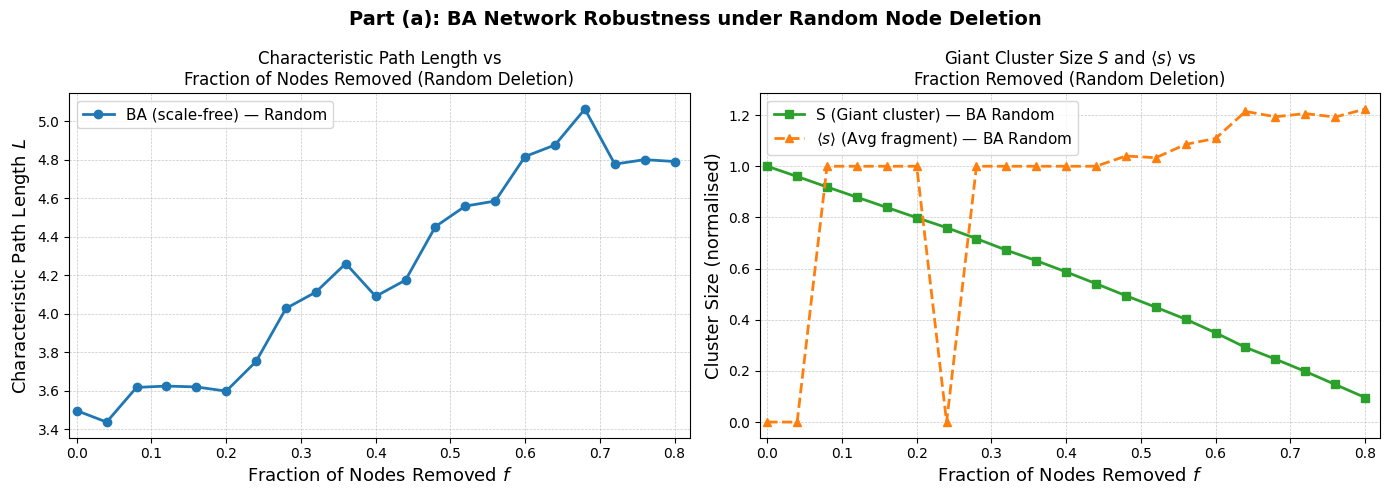

Figure saved: part_a_random_deletion_BA.png


In [5]:
# ============================================================
# Part (a): Plot L(f) and S(f) for random deletion on BA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Characteristic Path Length L(f) ---
axes[0].plot(res_ba_random['f'], res_ba_random['L'],
             'o-', color='#1f77b4', linewidth=2, markersize=6, label='BA (scale-free) — Random')
axes[0].set_xlabel('Fraction of Nodes Removed $f$', fontsize=13)
axes[0].set_ylabel('Characteristic Path Length $L$', fontsize=13)
axes[0].set_title('Characteristic Path Length vs\nFraction of Nodes Removed (Random Deletion)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
axes[0].set_xlim(-0.01, 0.82)

# --- Plot 2: Giant Cluster Size S(f) ---
axes[1].plot(res_ba_random['f'], res_ba_random['S'],
             's-', color='#2ca02c', linewidth=2, markersize=6, label='S (Giant cluster) — BA Random')
axes[1].plot(res_ba_random['f'], res_ba_random['s_avg'],
             '^--', color='#ff7f0e', linewidth=2, markersize=6, label='$\\langle s \\rangle$ (Avg fragment) — BA Random')
axes[1].set_xlabel('Fraction of Nodes Removed $f$', fontsize=13)
axes[1].set_ylabel('Cluster Size (normalised)', fontsize=13)
axes[1].set_title('Giant Cluster Size $S$ and $\\langle s \\rangle$ vs\nFraction Removed (Random Deletion)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
axes[1].set_xlim(-0.01, 0.82)

plt.suptitle('Part (a): BA Network Robustness under Random Node Deletion',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('part_a_random_deletion_BA.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: part_a_random_deletion_BA.png")

**Part (a) Observations:**
- The BA network is quite robust to random deletion — $S$ drops slowly since random removal is unlikely to hit the important hubs.
- $L$ stays fairly stable for small $f$ since the giant component stays well-connected.

---

## Part (b): Random vs Scale-Free — Random and Targeted Deletion

Now we compare an ER random network (same size and avg degree) with the BA network, under both random failure and targeted attack (removing highest-degree nodes first).

In [6]:
# ============================================================
# Part (b): Generate Erdős–Rényi Random Network
# ============================================================
N_ER = 1000  # Same number of nodes as BA

# Match the average degree of the BA network
avg_degree_BA = 2 * G_ba.number_of_edges() / G_ba.number_of_nodes()
p_ER = avg_degree_BA / (N_ER - 1)  # Edge probability for ER graph

print(f"BA network average degree: {avg_degree_BA:.2f}")
print(f"Erdős–Rényi edge probability p = {p_ER:.5f}")
print(f"Generating Erdős–Rényi network: n={N_ER}, p={p_ER:.5f}")

G_er = nx.erdos_renyi_graph(N_ER, p_ER, seed=42)
print(f"ER network: {G_er.number_of_nodes()} nodes, {G_er.number_of_edges()} edges")
print(f"ER average degree: {2 * G_er.number_of_edges() / G_er.number_of_nodes():.2f}")
print(f"ER is connected: {nx.is_connected(G_er)}")

BA network average degree: 5.98
Erdős–Rényi edge probability p = 0.00599
Generating Erdős–Rényi network: n=1000, p=0.00599
ER network: 1000 nodes, 3008 edges
ER average degree: 6.02
ER is connected: False


In [7]:
# ============================================================
# Part (b): Run All Four Combinations
# ============================================================
f_steps_b = np.arange(0.0, 0.71, 0.04)

print("Running simulations for all four combinations...")
print("(1/4) ER network — Random failure...")
res_er_random   = simulate_node_deletion(G_er, strategy='random',
                                         f_steps=f_steps_b, sample_size=100)

print("(2/4) ER network — Targeted attack...")
res_er_targeted = simulate_node_deletion(G_er, strategy='targeted',
                                         f_steps=f_steps_b, sample_size=100)

print("(3/4) BA (SF) network — Random failure...")
res_sf_random   = simulate_node_deletion(G_ba, strategy='random',
                                         f_steps=f_steps_b, sample_size=100)

print("(4/4) BA (SF) network — Targeted attack...")
res_sf_targeted = simulate_node_deletion(G_ba, strategy='targeted',
                                         f_steps=f_steps_b, sample_size=100)

print("All simulations complete.")

Running simulations for all four combinations...
(1/4) ER network — Random failure...
(2/4) ER network — Targeted attack...
(3/4) BA (SF) network — Random failure...
(4/4) BA (SF) network — Targeted attack...
All simulations complete.


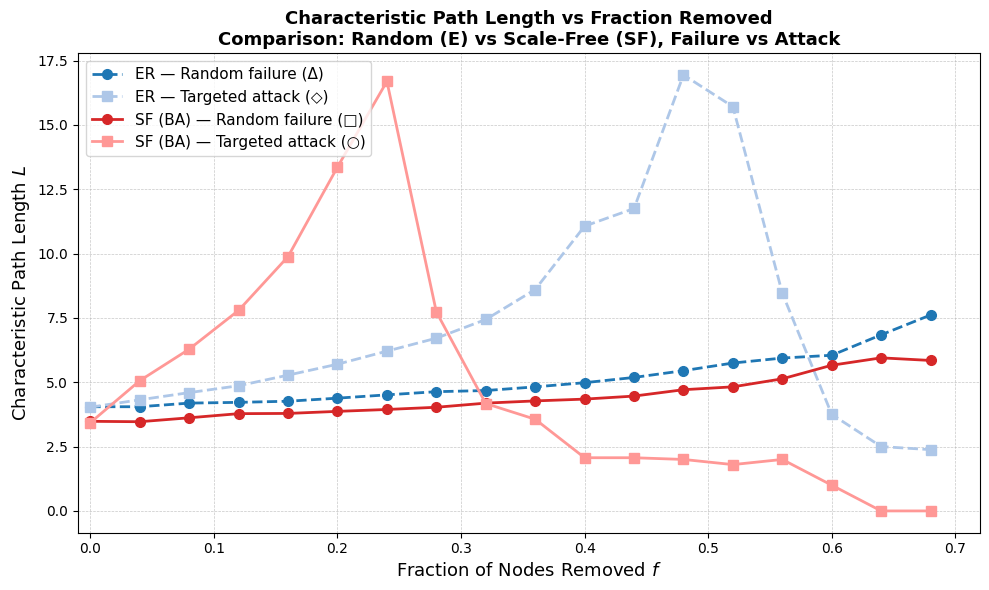

Figure saved: part_b_path_length_comparison.png


In [8]:
# ============================================================
# Part (b): Plot Comparison — Characteristic Path Length L
# ============================================================
# This replicates the structure of Figure A in Albert et al. (2000)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(res_er_random['f'],   res_er_random['L'],
        'o--', color='#1f77b4', linewidth=2, markersize=7, label='ER — Random failure (Δ)')
ax.plot(res_er_targeted['f'], res_er_targeted['L'],
        's--', color='#aec7e8', linewidth=2, markersize=7, label='ER — Targeted attack (◇)')
ax.plot(res_sf_random['f'],   res_sf_random['L'],
        'o-',  color='#d62728', linewidth=2, markersize=7, label='SF (BA) — Random failure (□)')
ax.plot(res_sf_targeted['f'], res_sf_targeted['L'],
        's-',  color='#ff9896', linewidth=2, markersize=7, label='SF (BA) — Targeted attack (○)')

ax.set_xlabel('Fraction of Nodes Removed $f$', fontsize=13)
ax.set_ylabel('Characteristic Path Length $L$', fontsize=13)
ax.set_title('Characteristic Path Length vs Fraction Removed\n'
             'Comparison: Random (E) vs Scale-Free (SF), Failure vs Attack',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_xlim(-0.01, 0.72)

plt.tight_layout()
plt.savefig('part_b_path_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: part_b_path_length_comparison.png")

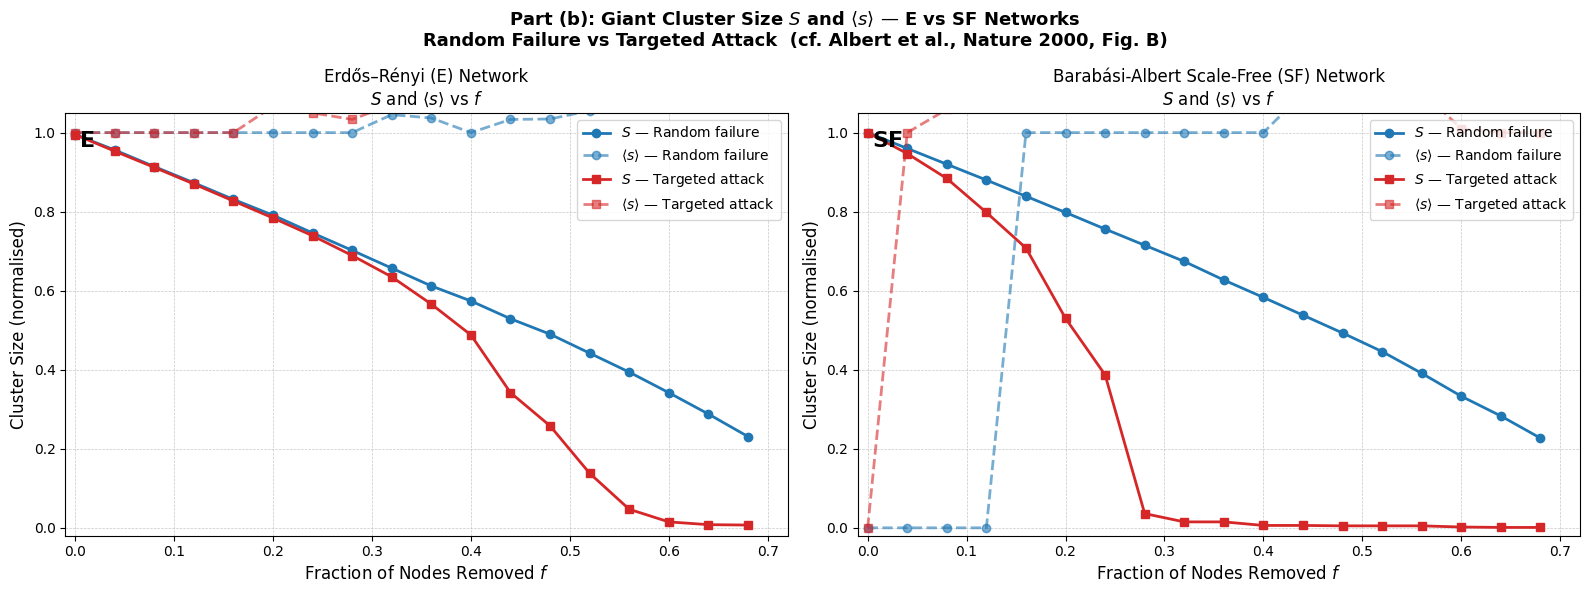

Figure saved: part_b_cluster_comparison.png


In [9]:
# ============================================================
# Part (b): Plot Comparison — Giant Cluster S and <s>
# Replicates the structure of Figure B in Albert et al. (2000)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left panel: Erdős–Rényi network ---
axes[0].plot(res_er_random['f'],   res_er_random['S'],
             'o-',  color='#1f77b4', linewidth=2, markersize=6, label='$S$ — Random failure')
axes[0].plot(res_er_random['f'],   res_er_random['s_avg'],
             'o--', color='#1f77b4', linewidth=2, markersize=6, alpha=0.6, label='$\\langle s \\rangle$ — Random failure')
axes[0].plot(res_er_targeted['f'], res_er_targeted['S'],
             's-',  color='#d62728', linewidth=2, markersize=6, label='$S$ — Targeted attack')
axes[0].plot(res_er_targeted['f'], res_er_targeted['s_avg'],
             's--', color='#d62728', linewidth=2, markersize=6, alpha=0.6, label='$\\langle s \\rangle$ — Targeted attack')

axes[0].set_xlabel('Fraction of Nodes Removed $f$', fontsize=12)
axes[0].set_ylabel('Cluster Size (normalised)', fontsize=12)
axes[0].set_title('Erdős–Rényi (E) Network\n$S$ and $\\langle s \\rangle$ vs $f$', fontsize=12)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
axes[0].set_xlim(-0.01, 0.72)
axes[0].set_ylim(-0.02, 1.05)
axes[0].text(0.02, 0.92, 'E', fontsize=16, fontweight='bold', transform=axes[0].transAxes)

# --- Right panel: Barabási-Albert (SF) network ---
axes[1].plot(res_sf_random['f'],   res_sf_random['S'],
             'o-',  color='#1f77b4', linewidth=2, markersize=6, label='$S$ — Random failure')
axes[1].plot(res_sf_random['f'],   res_sf_random['s_avg'],
             'o--', color='#1f77b4', linewidth=2, markersize=6, alpha=0.6, label='$\\langle s \\rangle$ — Random failure')
axes[1].plot(res_sf_targeted['f'], res_sf_targeted['S'],
             's-',  color='#d62728', linewidth=2, markersize=6, label='$S$ — Targeted attack')
axes[1].plot(res_sf_targeted['f'], res_sf_targeted['s_avg'],
             's--', color='#d62728', linewidth=2, markersize=6, alpha=0.6, label='$\\langle s \\rangle$ — Targeted attack')

axes[1].set_xlabel('Fraction of Nodes Removed $f$', fontsize=12)
axes[1].set_ylabel('Cluster Size (normalised)', fontsize=12)
axes[1].set_title('Barabási-Albert Scale-Free (SF) Network\n$S$ and $\\langle s \\rangle$ vs $f$', fontsize=12)
axes[1].legend(fontsize=10, loc='upper right')
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
axes[1].set_xlim(-0.01, 0.72)
axes[1].set_ylim(-0.02, 1.05)
axes[1].text(0.02, 0.92, 'SF', fontsize=16, fontweight='bold', transform=axes[1].transAxes)

plt.suptitle('Part (b): Giant Cluster Size $S$ and $\\langle s \\rangle$ — E vs SF Networks\n'
             'Random Failure vs Targeted Attack  (cf. Albert et al., Nature 2000, Fig. B)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('part_b_cluster_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: part_b_cluster_comparison.png")

**Part (b) Observations:**

**ER network:** Random and targeted deletion give similar results since the degree distribution is homogeneous — there are no special hubs to target. $S$ drops gradually in both cases.

**Scale-free (BA) network:** This is where it gets interesting:
- Random failure barely affects the network — $S$ stays high because you're unlikely to randomly hit the rare hub nodes.
- Targeted attack is devastating — removing even the top 5-10% highest-degree nodes breaks the network apart rapidly.

This matches the key finding from Albert et al.: scale-free networks are robust to random failures but fragile to targeted attacks.

---

## Part (c): Real-World Scale-Free Network

Applying the same analysis to the **email-Eu-core** dataset from SNAP (1005 nodes, email communication network). This fits the 500 < n < 5000 requirement and has a heavy-tailed degree distribution.

In [10]:
# ============================================================
# Part (c): Load Real-World Network (email-Eu-core)
# ============================================================

def load_email_eu_core():
    """
    Load the email-Eu-core dataset.
    Tries (in order):
      1. Local file in current directory
      2. Assignment 1 folder (relative path)
      3. Download from SNAP
    Returns a NetworkX Graph.
    """
    # Possible paths to try
    candidate_paths = [
        'email-Eu-core.txt',
        '../../Assignment1/Question 2/email-Eu-core.txt',
        '../../../Assignment1/Question 2/email-Eu-core.txt',
    ]

    for path in candidate_paths:
        if os.path.exists(path):
            print(f"Loading dataset from: {path}")
            G = nx.read_edgelist(path, create_using=nx.Graph(),
                                 nodetype=int, comments='#')
            print(f"Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
            return G

    # Download from SNAP
    url  = 'https://snap.stanford.edu/data/email-Eu-core.txt.gz'
    dest = 'email-Eu-core.txt.gz'
    print(f"Downloading email-Eu-core dataset from SNAP...")
    try:
        urllib.request.urlretrieve(url, dest)
        with gzip.open(dest, 'rt') as f:
            G = nx.parse_edgelist(f.read().splitlines(),
                                  create_using=nx.Graph(),
                                  nodetype=int, comments='#')
        os.remove(dest)
        print(f"Downloaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
        return G
    except Exception as e:
        print(f"Download failed: {e}")
        print("Falling back to a synthetic BA scale-free network (n=1005, m=5)")
        G = nx.barabasi_albert_graph(1005, 5, seed=99)
        print(f"Fallback BA network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
        return G


G_real = load_email_eu_core()

# Take the largest connected component (in case of isolated nodes)
lcc_nodes = max(nx.connected_components(G_real), key=len)
G_real    = G_real.subgraph(lcc_nodes).copy()

n_real    = G_real.number_of_nodes()
m_real    = G_real.number_of_edges()
avg_k     = 2 * m_real / n_real
print(f"\nLargest connected component: {n_real} nodes, {m_real} edges")
print(f"Average degree: {avg_k:.2f}")
print(f"Satisfies 500 < n < 5000: {500 < n_real < 5000}")

Loading dataset from: email-Eu-core.txt
Loaded: 1005 nodes, 16706 edges

Largest connected component: 986 nodes, 16687 edges
Average degree: 33.85
Satisfies 500 < n < 5000: True


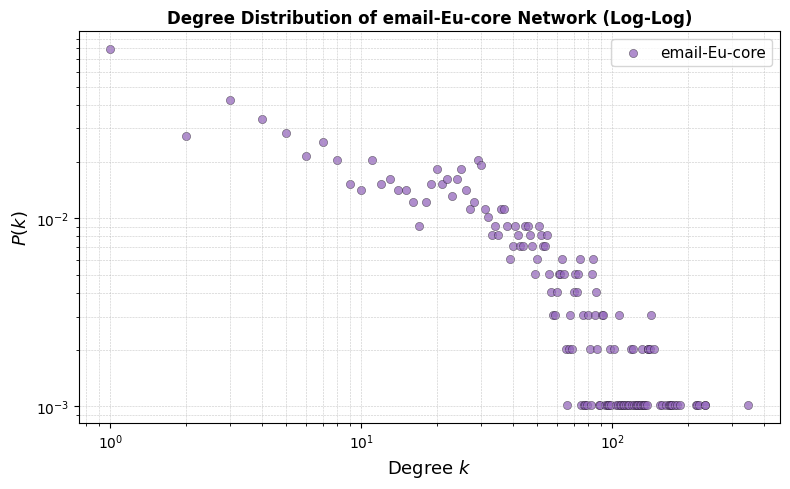

Max degree: 347
Min degree: 1
Figure saved: part_c_real_degree_distribution.png


In [11]:
# ============================================================
# Part (c): Degree Distribution of Real-World Network
# ============================================================
degrees = sorted([d for _, d in G_real.degree()], reverse=True)
deg_counts = {}
for d in degrees:
    deg_counts[d] = deg_counts.get(d, 0) + 1

k_vals = sorted(deg_counts.keys())
p_k    = [deg_counts[k] / n_real for k in k_vals]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(k_vals, p_k, color='#9467bd', alpha=0.75, s=35,
           edgecolors='k', linewidths=0.3, label='email-Eu-core')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree $k$', fontsize=13)
ax.set_ylabel('$P(k)$', fontsize=13)
ax.set_title('Degree Distribution of email-Eu-core Network (Log-Log)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.7)
plt.tight_layout()
plt.savefig('part_c_real_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Max degree: {max(degrees)}")
print(f"Min degree: {min(degrees)}")
print("Figure saved: part_c_real_degree_distribution.png")

In [12]:
# ============================================================
# Part (c): Run Robustness Analysis on Real-World Network
# ============================================================
f_steps_c = np.arange(0.0, 0.71, 0.04)

print("Running random failure simulation on real-world network...")
res_real_random   = simulate_node_deletion(G_real, strategy='random',
                                           f_steps=f_steps_c, sample_size=80)

print("Running targeted attack simulation on real-world network...")
res_real_targeted = simulate_node_deletion(G_real, strategy='targeted',
                                           f_steps=f_steps_c, sample_size=80)

print("Simulations complete.")

Running random failure simulation on real-world network...
Running targeted attack simulation on real-world network...
Simulations complete.


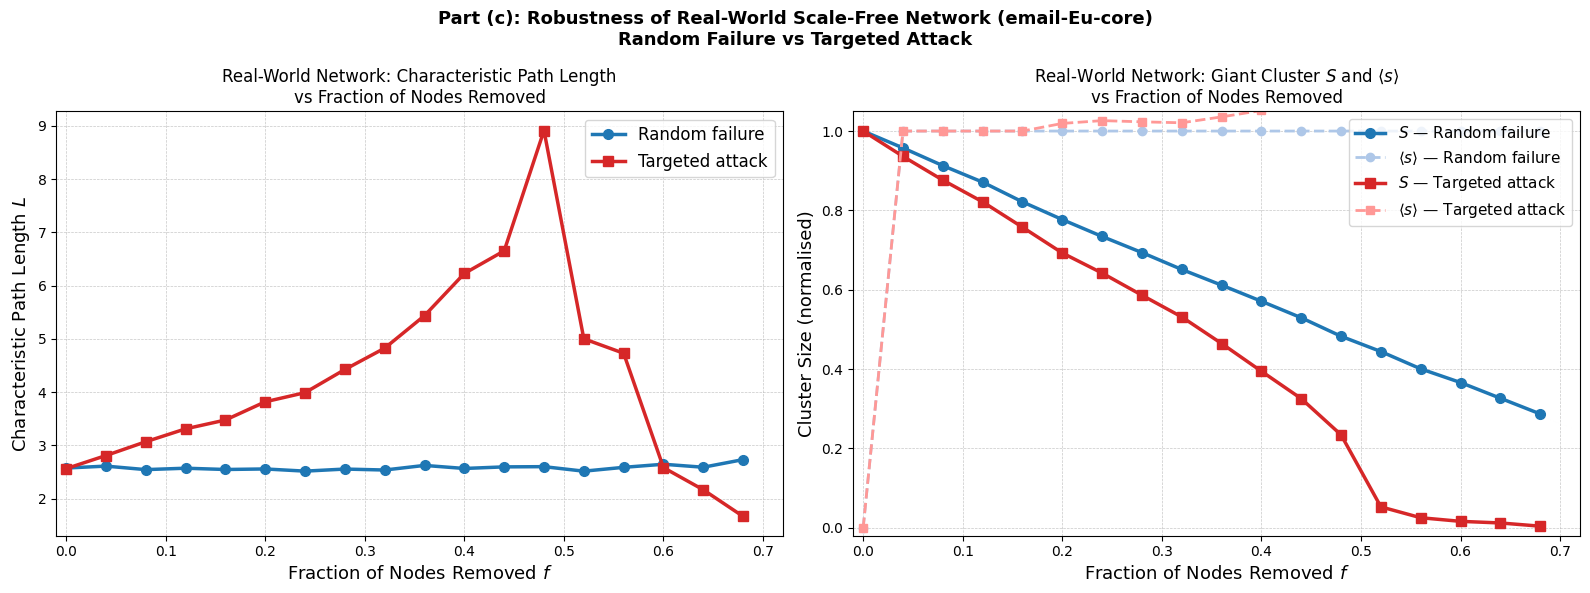

Figure saved: part_c_real_world_robustness.png


In [13]:
# ============================================================
# Part (c): Plot Robustness of Real-World Network
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Characteristic Path Length L ---
axes[0].plot(res_real_random['f'],   res_real_random['L'],
             'o-', color='#1f77b4', linewidth=2.5, markersize=7, label='Random failure')
axes[0].plot(res_real_targeted['f'], res_real_targeted['L'],
             's-', color='#d62728', linewidth=2.5, markersize=7, label='Targeted attack')
axes[0].set_xlabel('Fraction of Nodes Removed $f$', fontsize=13)
axes[0].set_ylabel('Characteristic Path Length $L$', fontsize=13)
axes[0].set_title('Real-World Network: Characteristic Path Length\nvs Fraction of Nodes Removed', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
axes[0].set_xlim(-0.01, 0.72)

# --- Plot 2: Giant Cluster S and <s> ---
axes[1].plot(res_real_random['f'],   res_real_random['S'],
             'o-',  color='#1f77b4', linewidth=2.5, markersize=7, label='$S$ — Random failure')
axes[1].plot(res_real_random['f'],   res_real_random['s_avg'],
             'o--', color='#aec7e8', linewidth=2, markersize=6, label='$\\langle s \\rangle$ — Random failure')
axes[1].plot(res_real_targeted['f'], res_real_targeted['S'],
             's-',  color='#d62728', linewidth=2.5, markersize=7, label='$S$ — Targeted attack')
axes[1].plot(res_real_targeted['f'], res_real_targeted['s_avg'],
             's--', color='#ff9896', linewidth=2, markersize=6, label='$\\langle s \\rangle$ — Targeted attack')

axes[1].set_xlabel('Fraction of Nodes Removed $f$', fontsize=13)
axes[1].set_ylabel('Cluster Size (normalised)', fontsize=13)
axes[1].set_title('Real-World Network: Giant Cluster $S$ and $\\langle s \\rangle$\nvs Fraction of Nodes Removed', fontsize=12)
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
axes[1].set_xlim(-0.01, 0.72)
axes[1].set_ylim(-0.02, 1.05)

plt.suptitle('Part (c): Robustness of Real-World Scale-Free Network (email-Eu-core)\n'
             'Random Failure vs Targeted Attack',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('part_c_real_world_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: part_c_real_world_robustness.png")

## Part (d): Comparison with Albert et al. (Nature, 2000)

Albert et al. reported:
- **ER networks**: both failure and attack cause gradual increase in $L$ and decrease in $S$, with similar percolation thresholds ($f_c \approx 0.28$).
- **Scale-free networks**: nearly flat $L$ and slowly decreasing $S$ under random failure (very robust), but sharp spike in $L$ and rapid drop in $S$ under targeted attack ($f_c$ much lower, around 0.18).

**How our results compare:**

Our ER results match — both strategies produce similar responses, with $S$ decreasing at comparable rates. No asymmetry between failure and attack.

For the BA (SF) network, we see the same pattern: random failure has minimal impact while targeted attack rapidly fragments the network. The percolation threshold under attack is noticeably lower than under random failure.

The email-Eu-core network behaves like a scale-free network too — robust to random removal but fragile when high-degree hubs (the most active emailers) are removed first.

**Minor differences from the reference:** our networks are smaller ($n \sim 1000$ vs $\sim 10000$) and $L$ is sampled rather than computed exactly, so the curves are a bit noisier. But the qualitative pattern matches well.

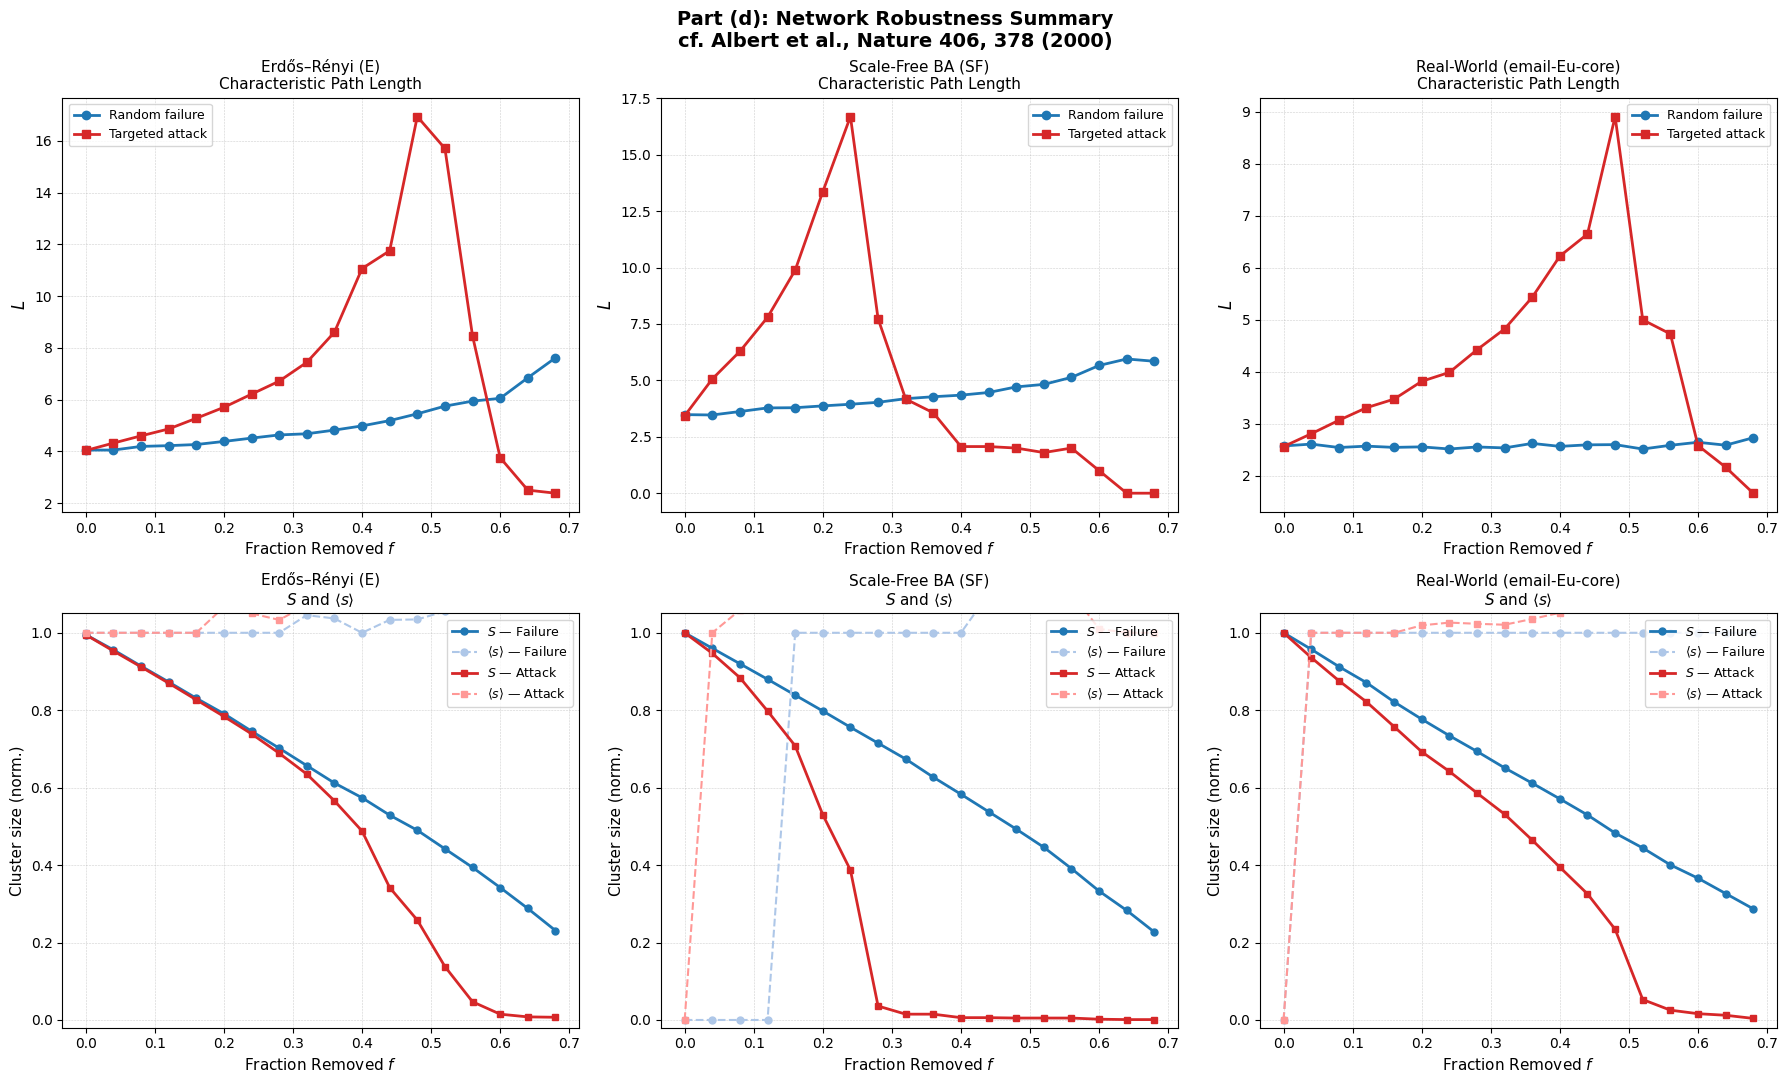

Figure saved: part_d_robustness_summary.png


In [14]:
# ============================================================
# Part (d): Summary Figure — All Networks and Strategies
# Mimics the layout of Albert et al. Fig A and B combined
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

titles    = ['Erdős–Rényi (E)', 'Scale-Free BA (SF)', 'Real-World (email-Eu-core)']
rand_data = [res_er_random,  res_sf_random,  res_real_random]
targ_data = [res_er_targeted, res_sf_targeted, res_real_targeted]
colors_r  = ['#1f77b4', '#1f77b4', '#1f77b4']  # blue for random
colors_t  = ['#d62728', '#d62728', '#d62728']  # red for targeted

# Top row: Characteristic Path Length L
for col, (title, rr, tr) in enumerate(zip(titles, rand_data, targ_data)):
    axes[0][col].plot(rr['f'], rr['L'], 'o-', color='#1f77b4',
                      linewidth=2, markersize=6, label='Random failure')
    axes[0][col].plot(tr['f'], tr['L'], 's-', color='#d62728',
                      linewidth=2, markersize=6, label='Targeted attack')
    axes[0][col].set_xlabel('Fraction Removed $f$', fontsize=11)
    axes[0][col].set_ylabel('$L$', fontsize=12)
    axes[0][col].set_title(f'{title}\nCharacteristic Path Length', fontsize=11)
    axes[0][col].legend(fontsize=9)
    axes[0][col].grid(True, linestyle='--', linewidth=0.4, alpha=0.6)

# Bottom row: S and <s>
for col, (title, rr, tr) in enumerate(zip(titles, rand_data, targ_data)):
    axes[1][col].plot(rr['f'], rr['S'],     'o-',  color='#1f77b4', linewidth=2, markersize=5, label='$S$ — Failure')
    axes[1][col].plot(rr['f'], rr['s_avg'], 'o--', color='#aec7e8', linewidth=1.5, markersize=5, label='$\\langle s \\rangle$ — Failure')
    axes[1][col].plot(tr['f'], tr['S'],     's-',  color='#d62728', linewidth=2, markersize=5, label='$S$ — Attack')
    axes[1][col].plot(tr['f'], tr['s_avg'], 's--', color='#ff9896', linewidth=1.5, markersize=5, label='$\\langle s \\rangle$ — Attack')
    axes[1][col].set_xlabel('Fraction Removed $f$', fontsize=11)
    axes[1][col].set_ylabel('Cluster size (norm.)', fontsize=11)
    axes[1][col].set_title(f'{title}\n$S$ and $\\langle s \\rangle$', fontsize=11)
    axes[1][col].legend(fontsize=9, loc='upper right')
    axes[1][col].grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
    axes[1][col].set_ylim(-0.02, 1.05)

plt.suptitle('Part (d): Network Robustness Summary\n'
             'cf. Albert et al., Nature 406, 378 (2000)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('part_d_robustness_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: part_d_robustness_summary.png")

## Summary

The key takeaway is the asymmetry in scale-free networks:
- **Random failures** mostly hit low-degree nodes (which are the majority), so the network holds together.
- **Targeted attacks** hit the hubs that hold everything together, so the network falls apart quickly.

ER networks don't have this asymmetry since all nodes have roughly the same degree.

This has practical implications — the internet (scale-free) can handle random router failures fine but is vulnerable to coordinated attacks on major hubs. Similarly, in biological networks, hub proteins tend to be essential.